# Pushoverr Weather Forecast

**Author:** Christian Kruse  
**Date:** `r Sys.Date()`

In [ ]:
# setwd(".")  # Set working directory if needed

In [27]:
knitr::opts_chunk$set(echo = FALSE,message = FALSE,warning = FALSE)

# Pushoverr Weather Forecast

In [28]:
if (!require(pacman)) { install.packages("pacman") }
pacman::p_load(pushoverr,
               dplyr,
               tidyr,
               lubridate,
               scales,
               httr,
               ggplot2,
               suncalc,
               glue,
               hms,
               stringr,
               data.table)

Loading required package: pacman



In [29]:
readRenviron(path = "Renviron.site")
OPENWEATHERMAP_APIKEY = Sys.getenv("OPENWEATHERMAP_APIKEY")

# Check if Pushover credentials are available
pushover_app_key <- Sys.getenv("PUSHOVER_APPKEY")
pushover_user_key <- Sys.getenv("PUSHOVER_USERKEY")

if (nchar(pushover_app_key) == 0) {
  cat("Warning: PUSHOVER_APPKEY not found in environment variables\n")
  cat("Available environment variables with 'PUSHOVER':\n")
  print(Sys.getenv()[grepl("PUSHOVER", names(Sys.getenv()))])
} else {
  pushoverr::set_pushover_app(token = pushover_app_key)
  cat("Pushover app token set successfully\n")
}

if (nchar(pushover_user_key) == 0) {
  cat("Warning: PUSHOVER_USERKEY not found in environment variables\n")
} else {
  pushoverr::set_pushover_user(user = pushover_user_key)
  cat("Pushover user key set successfully\n")
}

Warning message in readRenviron(path = "Renviron.site"):
“file 'Renviron.site' cannot be opened for reading”


Available environment variables with 'PUSHOVER':



In [30]:
# This cell is set to eval=FALSE in original
# pushoverr::pushover("Hello world")

In [31]:
convert_timestamp = function(timestamp) {
  return( as.POSIXct( timestamp ,tz = "Europe/Copenhagen",origin="1970-01-01") )
}

In [32]:
convert_dataframe_timestamps = function(df) {
  df$dt = convert_timestamp(df$dt)
  df$sunrise = convert_timestamp(df$sunrise)
  df$sunset = convert_timestamp(df$sunset)
  df$moonrise = convert_timestamp(df$moonrise)
  df$moonset = convert_timestamp(df$moonset)
  return( df )
}

In [33]:
wind_angle_to_compass = function(angle)  {
    val = (angle + 11.25)/22.5
    arr = c("N", "NNE", "NE", "ENE", "E", "ESE", "SE", "SSE", "S", "SSW", "SW", "WSW", "W", "WNW", "NW", "NNW")
    return( arr[(val %% 16)] )
}

In [34]:
convert_kelvin= function(kelvin) {
  return( kelvin - 273.15 )
}

In [35]:
lat = 55.771979
lon = 12.494786

OPENWEATHERMAP_APIKEY = Sys.getenv("OPENWEATHERMAP_APIKEY")
res = GET(paste0("https://api.openweathermap.org/data/3.0/onecall?lat=",lat,"&lon=",lon,"&appid=",OPENWEATHERMAP_APIKEY)) # Yeah, should really hide that api key.


In [36]:
res

In [37]:
res_json = jsonlite::fromJSON( rawToChar( res$content ) )
# Use str() to view structure and avoid rich display errors with complex objects
str(res_json, max.level = 1)

List of 8
 $ lat            : num 55.8
 $ lon            : num 12.5
 $ timezone       : chr "Europe/Copenhagen"
 $ timezone_offset: int 3600
 $ current        :List of 14
 $ minutely       :'data.frame':	60 obs. of  2 variables:
 $ hourly         :'data.frame':	48 obs. of  14 variables:
 $ daily          :'data.frame':	8 obs. of  20 variables:


In [38]:

res_json_current = res_json$current
res_json_daily = res_json$daily
res_json_hourly = res_json$hourly
res_json_minutely = res_json$minutely

res_json_daily = convert_dataframe_timestamps(res_json_daily)
res_json_current = convert_dataframe_timestamps(res_json_current)
res_json_hourly$dt = convert_timestamp(res_json_hourly$dt)
res_json_minutely$dt = convert_timestamp(res_json_minutely$dt)

res_json_current$temp = convert_kelvin( res_json_current$temp )
res_json_current$feels_like = convert_kelvin( res_json_current$feels_like )
res_json_current$dew_point = convert_kelvin( res_json_current$dew_point )

res_json_hourly$temp = convert_kelvin( res_json_hourly$temp )
res_json_hourly$feels_like = convert_kelvin( res_json_hourly$feels_like )
res_json_hourly$dew_point = convert_kelvin( res_json_hourly$dew_point )

# Openweather: Current Weather

So you don't need to look out the window. :-)

* Time: ```r res_json_current$dt ```
* Weather Description: ```r res_json_current$weather$description ```
* Temperature (C): ```r res_json_current$temp ```
* Feels Like (C): ```r res_json_current$feels_like ```
* Pressure (hPa): ```r res_json_current$pressure ```
* Humidity: ```r res_json_current$humidity ```
* Dew Point: ```r res_json_current$dew_point ```
* UVI Index: ```r res_json_current$uvi ```
* Clouds: ```r res_json_current$clouds ```
* Visibility: ```r res_json_current$visibility ```
* Wind Speed: ```r res_json_current$wind_speed ```
* Wind Degree: ```r res_json_current$wind_deg ```
* Wind Direction: ```r wind_angle_to_compass( res_json_current$wind_deg )```

# Openweather: Today Outdoors Weather

In [39]:
rescale_capped = function(values,from) {
  
  if (from[2]>from[1]) {
    values = pmin(from[2],values)
    values = pmax(from[1],values)
    return( (values-from[1])/(from[2] - from[1]) * 100 )
  } else {
    values = pmin(from[1],values)
    values = pmax(from[2],values)
    #values = from[1] - values
    return( (values-from[1])/(from[2] - from[1]) * 100 )
    
  }
}

In [40]:
res_json_hourly

,dt,temp,feels_like,pressure,humidity,dew_point,uvi,clouds,visibility,wind_speed,wind_deg,wind_gust,weather,pop
,<dttm>,<dbl>,<dbl>,<int>,<int>,<dbl>,<dbl>,<int>,<int>,<dbl>,<int>,<dbl>,<list>,<int>
1,2026-03-06 10:00:00,7.87,5.54,1024,62,1.05,0.91,0,10000,3.71,157,7.11,"800 , Clear , clear sky, 01d",0
2,2026-03-06 11:00:00,8.21,5.78,1024,61,1.14,1.26,0,10000,4.04,163,7.36,"800 , Clear , clear sky, 01d",0
3,2026-03-06 12:00:00,8.20,5.86,1024,60,0.91,1.41,0,10000,3.87,169,6.87,"800 , Clear , clear sky, 01d",0
4,2026-03-06 13:00:00,8.52,6.28,1024,57,0.50,1.30,0,10000,3.80,166,6.51,"800 , Clear , clear sky, 01d",0
5,2026-03-06 14:00:00,8.95,7.02,1024,53,-0.09,1.00,0,10000,3.39,169,5.70,"800 , Clear , clear sky, 01d",0
6,2026-03-06 15:00:00,9.23,7.54,1024,52,-0.09,0.62,0,10000,3.08,163,4.77,"800 , Clear , clear sky, 01d",0
7,2026-03-06 16:00:00,8.83,7.22,1024,51,-0.67,0.29,0,10000,2.82,161,4.42,"800 , Clear , clear sky, 01d",0
8,2026-03-06 17:00:00,7.31,5.61,1024,58,-0.31,0.00,6,10000,2.54,160,4.43,"800 , Clear , clear sky, 01d",0
9,2026-03-06 18:00:00,5.45,3.48,1024,63,-0.37,0.00,23,10000,2.44,160,4.28,"801 , Clouds , few clouds, 02n",0


In [41]:
df.scores = res_json_hourly %>% 
  filter(dt<=ymd_hms(paste0(Sys.Date()," 00:00:00"),tz = "Europe/Copenhagen")+days(1)) %>% 
  dplyr::mutate(dt=format(dt,"%H:%M"),
                pop=pop*100) 

if ( !is.null(res_json_hourly$rain) ) {
  df.scores_rain = res_json_hourly %>% 
  dplyr::select(dt,rain) %>% 
  unnest(rain) %>% 
  replace_na(list(`1h`=0)) %>% 
  filter(dt<=ymd_hms(paste0(Sys.Date()," 00:00:00"),tz = "Europe/Copenhagen")+days(1)) %>% 
  dplyr::mutate(dt=format(dt,"%H:%M")) %>% 
  setNames(.,c("dt","rainmm"))
} else {
  df.scores_rain = res_json_hourly %>% 
  dplyr::select(dt) %>% 
  filter(dt<=ymd_hms(paste0(Sys.Date()," 00:00:00"),tz = "Europe/Copenhagen")+days(1)) %>% 
  dplyr::mutate(dt=format(dt,"%H:%M"),
                rainmm=0)
}


df.scores = df.scores %>% 
  inner_join(df.scores_rain)

df.scores = df.scores %>% 
  # dplyr::mutate(rain_score=rescale_capped(rain,from = c(10,0))) %>% 
  dplyr::mutate(temp_score=rescale_capped(temp,from = c(0,25))) %>% 
  dplyr::mutate(feels_like_score=rescale_capped(feels_like,from = c(0,25))) %>% 
  dplyr::mutate(humidity_score=rescale_capped(humidity,from = c(100,0))) %>% 
  dplyr::mutate(dew_point_score=rescale_capped(dew_point,from = c(0,20))) %>% 
  dplyr::mutate(uvi_score=rescale_capped(uvi,from = c(0,6))) %>% 
  dplyr::mutate(clouds_score=rescale_capped(clouds,from = c(100,0))) %>% 
  dplyr::mutate(wind_speed_score=rescale_capped(wind_speed,from = c(10,0))) %>% 
  dplyr::mutate(wind_gust_score=rescale_capped(wind_gust,from = c(10,0))) %>% 
  dplyr::mutate(pop_score=rescale_capped(pop,from = c(100,0)))  %>% 
  dplyr::mutate(rainmm_score=rescale_capped(rainmm,from = c(100,0))) %>% 
  dplyr::mutate(
    # Calculate absolute humidity using tetens equation
    vapor_pressure = humidity * 0.01 * 6.11 * 10^((7.5 * temp)/(237.3 + temp)),
    water_content = 2165 * vapor_pressure / (273.15 + temp),
    
    # Calculate equivalent humidity at reference temperature (21C)
    vapor_press_21 = 6.11 * 10^((7.5 * 21)/(237.3 + 21)),
    max_water_21 = 2165 * vapor_press_21 / (273.15 + 21),
    adjusted_humidity_21c = 100 * water_content / max_water_21
  ) %>%
  dplyr::mutate(
    water_content_score = rescale_capped(water_content, from = c(20, 0)),
    adjusted_humidity_21c_score = rescale_capped(adjusted_humidity_21c, from = c(100, 0))
  )

Joining with `by = join_by(dt)`


In [42]:
draw_scorecard = function(factors) {
  
## First get DT and score

df.score = df.scores %>% 
  dplyr::select(dt,contains(factors),contains(paste0(factors,"_score")))

num_cols = sum(grepl("_score",colnames(df.score)))

df.score = df.score %>% 
  dplyr::mutate(score = round(100*rowSums(across(contains("_score")))/(num_cols*100))) %>% 
  dplyr::select(dt,score,contains(factors),-contains("_score"))

df.dt_score = df.score %>% 
  dplyr::select(dt,score)

# Max score

# Then gather and join on score
df.score %>% 
  dplyr::select(dt,score,contains(factors)) %>% 
  gather(metric,value,score:ncol(.)) %>% 
  inner_join(df.dt_score, by = "dt") %>% 
  dplyr::mutate(dt=factor(dt,levels=paste0(str_pad(c(seq(1,23,1),0),width = 2,side = "left",pad = "0"),":00"))) %>% 
  dplyr::mutate(metric=factor(metric,levels=c("score",factors))) %>% 
  ggplot(.,aes(x=metric,y=dt)) +
  geom_tile(aes(fill=score)) + 
  scale_fill_gradient2(low="red",mid="white",high="green",midpoint=50,limits = c(0,100)) +
  geom_text(aes(label=paste0(ifelse(metric %in% c("uvi","temp","dew_point","rainmm"),round(value,1),round(value,0)))),color="black") +
  theme_bw() +
  theme(legend.position="null") +
  labs(x=NULL,
       y=NULL,
       title = paste0("Sun Forecast: ",format.Date(Sys.Date(),"%A %d. %B, %Y"))) + 
  scale_x_discrete(labels=c("score" = "Score 0-100",
                            "temp" = "Temperature (C)",
                            "humidity" = "Humidity (%)",
                            "water_content" = "Water Content (g/m³)",
                            "adjusted_humidity_21c" = "Adj. Humidity @ 21C (%)",
                            "dew_point" = "Dew Point (C)",
                            "uvi" = "UV Index",
                            "clouds" = "Clouds (%)",
                            "pop" = "Precipitation (%)",
                            "rainmm" = "Rain (mm)",
                            "wind_speed" = "Wind Speed (m/s)",
                            "wind_gust" = "Wind Gusts (m/s)"))



}

# Autumn/winter

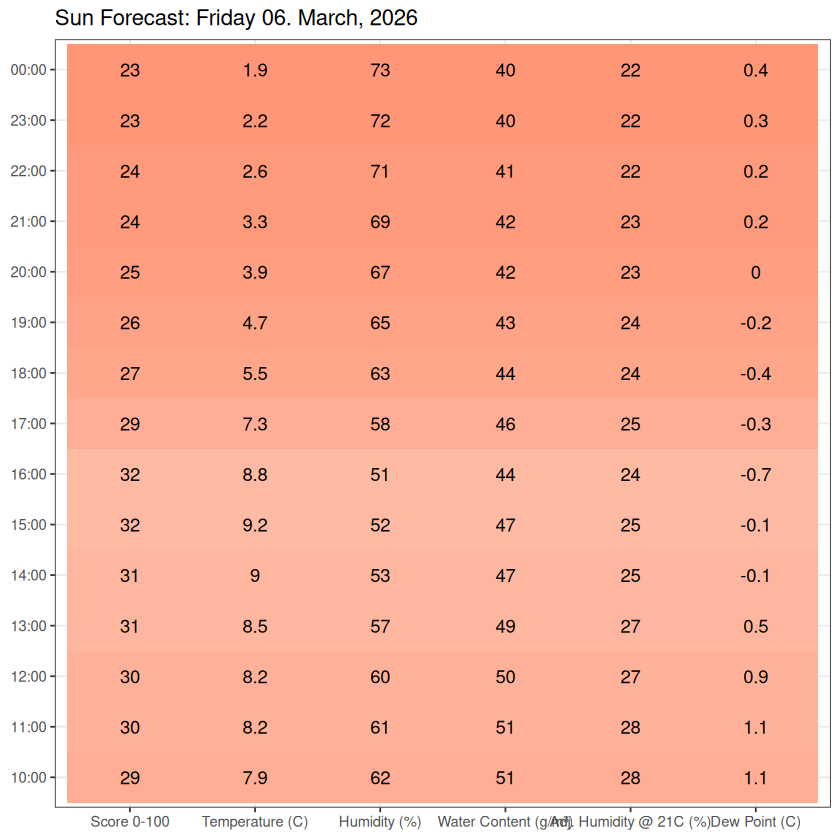

In [43]:
# Include new metrics in autumn/winter view
order_autumn_winter = c("temp", "humidity", "water_content", "adjusted_humidity_21c", 
                        "dew_point")
autumn_winter_forecast = draw_scorecard(factors = order_autumn_winter)
autumn_winter_forecast

[1] "Test case (should be ~11.64 g/m³):"
  temp humidity      svp water_content
1   22       60 26.42829      11.64438


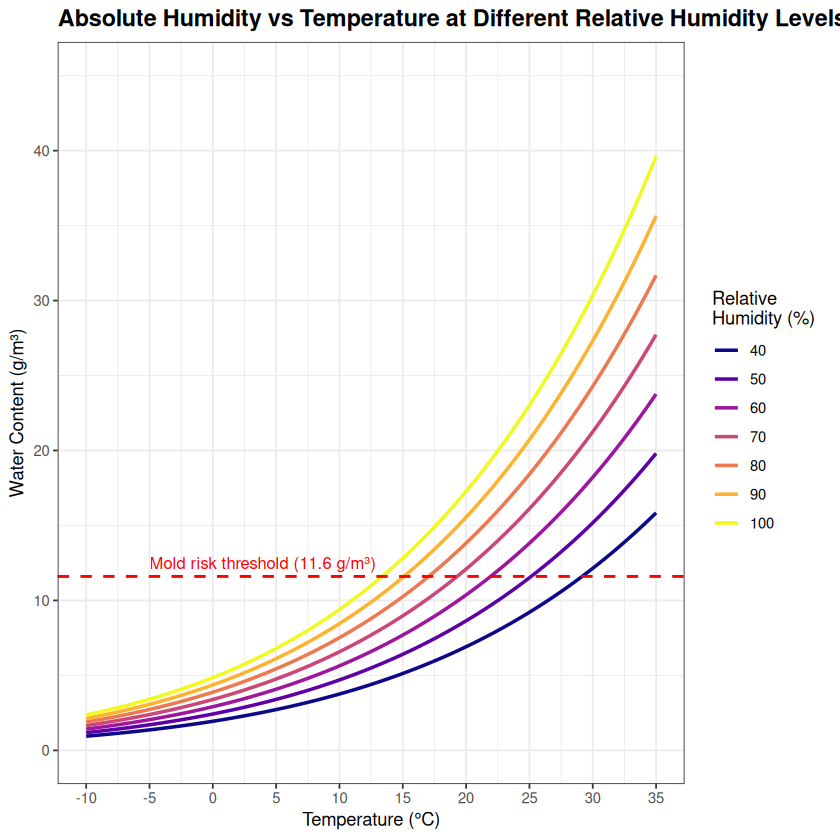

In [44]:
# Create a plot showing water content vs temperature for different humidity levels
library(ggplot2)
library(dplyr)

# Create a data frame with temperature range and humidity levels
temp_range <- seq(-10, 35, by = 0.5)
humidity_levels <- c(40, 50, 60, 70, 80, 90, 100)

# Calculate water content for each combination
water_content_data <- expand.grid(
  temp = temp_range,
  humidity = humidity_levels
) %>%
  mutate(
    # Calculate Saturated Vapor Pressure using Magnus formula (in hPa)
    svp = 6.112 * exp((17.67 * temp) / (temp + 243.5)),
    
    # Calculate absolute humidity (water content in g/m³)
    # Note: humidity is in % (e.g., 60), so divide by 100
    water_content = (humidity * svp * 2.1674) / (273.15 + temp)
  )

# Verify calculation with test case
test_case <- water_content_data %>%
  filter(temp == 22, humidity == 60) %>%
  select(temp, humidity, svp, water_content)

print("Test case (should be ~11.64 g/m³):")
print(test_case)

# Create the plot
p_water_content <- ggplot(water_content_data, aes(x = temp, y = water_content, color = factor(humidity))) +
  geom_line(linewidth = 1) +
  geom_hline(yintercept = 11.6, linetype = "dashed", color = "red", linewidth = 0.8) +
  annotate("text", x = -5, y = 12.5, label = "Mold risk threshold (11.6 g/m³)", 
           color = "red", hjust = 0, size = 3.5) +
  theme_bw() +
  labs(
    x = "Temperature (°C)",
    y = "Water Content (g/m³)",
    color = "Relative\nHumidity (%)",
    title = "Absolute Humidity vs Temperature at Different Relative Humidity Levels"
  ) +
  scale_color_viridis_d(option = "plasma") +
  theme( 
    legend.position = "right",
    plot.title = element_text(size = 14, face = "bold")
  ) +
  scale_x_continuous(breaks = seq(-10, 35, by = 5)) +
  coord_cartesian(ylim = c(0, 45))

p_water_content

## Outdoor Sun

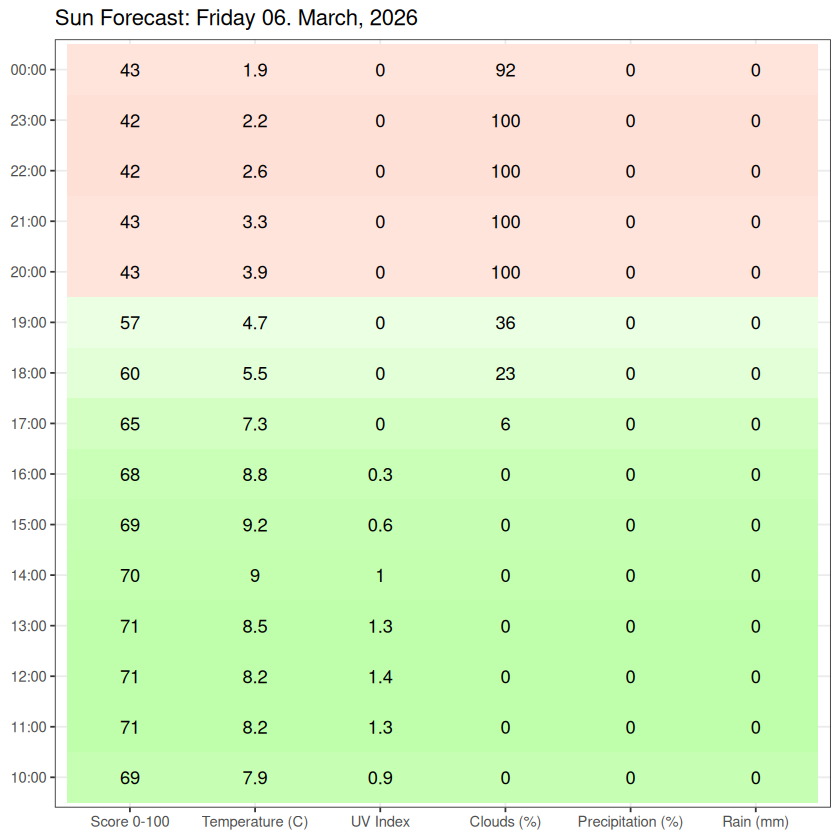

In [45]:
order = c("temp","uvi","clouds","pop","rainmm")
todays_forecast = draw_scorecard(order)
todays_forecast

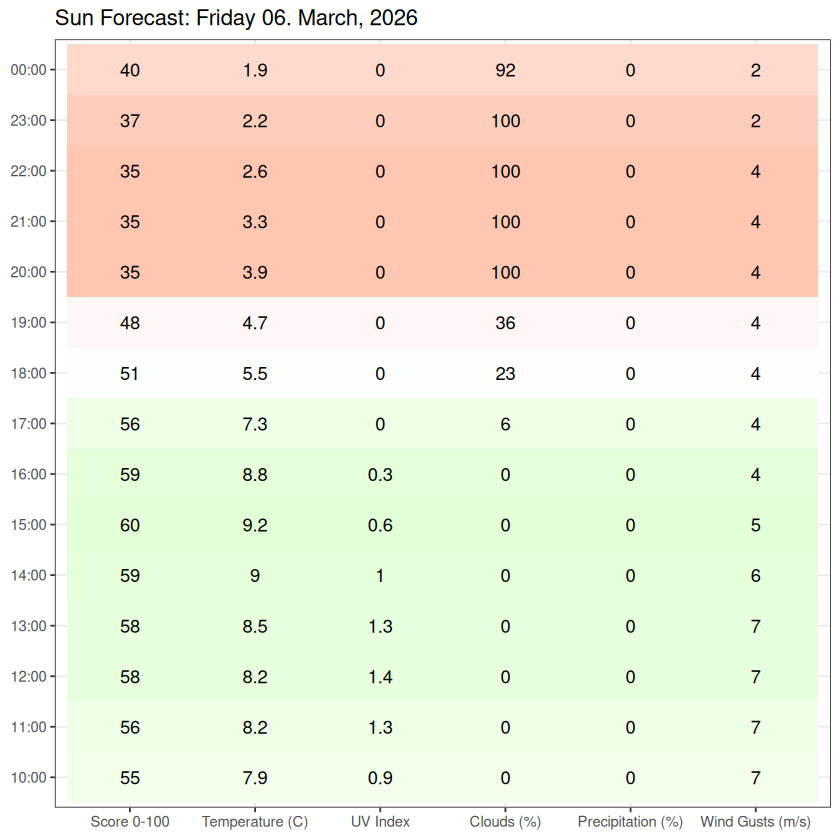

In [46]:
order_beach_forecast = c("temp","uvi","clouds","pop","wind_gust")
todays_beach_forecast = draw_scorecard(factors = order_beach_forecast)
todays_beach_forecast

In [47]:
## First get DT and score

df.scores = res_json_hourly %>% 
  filter(!hour(dt) %in% c(23,seq(0,6) )) %>% 
  arrange(dt) %>% 
  dplyr::mutate(hour_=hour(dt),
                dt=factor(format(dt,"%A %H:%M"),levels=format(dt,"%A %H:%M")),
                pop=pop*100)
# %>% 
  # dplyr::mutate(rain=.$rain$`1h`)

# df.scores$rain[is.na(df.scores$rain)] <- 0

df.scores = df.scores %>% 
  # dplyr::mutate(rain_score=rescale_capped(rain,from = c(10,0))) %>% 
  dplyr::mutate(temp_score=rescale_capped(temp,from = c(0,25))) %>% 
  dplyr::mutate(feels_like_score=rescale_capped(feels_like,from = c(0,25))) %>% 
  dplyr::mutate(humidity_score=rescale_capped(humidity,from = c(100,0))) %>% 
  dplyr::mutate(uvi_score=rescale_capped(uvi,from = c(0,6))) %>% 
  dplyr::mutate(clouds_score=rescale_capped(clouds,from = c(100,0))) %>% 
  dplyr::mutate(wind_speed_score=rescale_capped(wind_speed,from = c(10,0))) %>% 
  dplyr::mutate(wind_gust_score=rescale_capped(wind_gust,from = c(10,0))) %>% 
  dplyr::mutate(pop_score=rescale_capped(pop,from = c(100,0)))

Joining with `by = join_by(dt)`


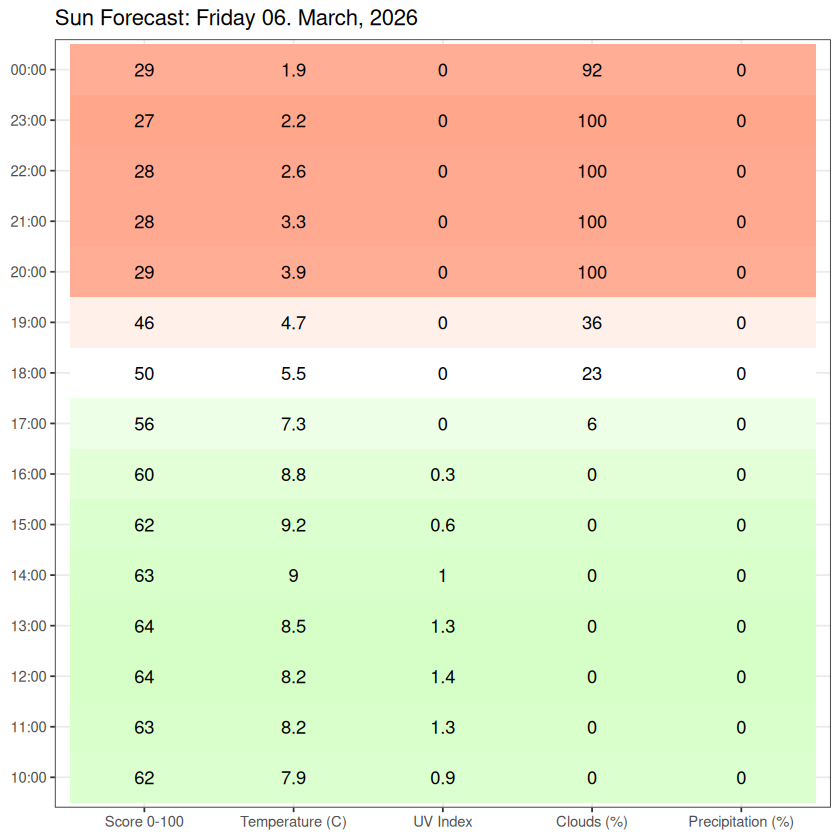

In [48]:
# Rebuild df.scores with the correct format for draw_scorecard (using HH:MM format)
df.scores_card = res_json_hourly %>% 
  filter(dt<=ymd_hms(paste0(Sys.Date()," 00:00:00"),tz = "Europe/Copenhagen")+days(1)) %>% 
  dplyr::mutate(dt=format(dt,"%H:%M"),
                pop=pop*100) 

if ( !is.null(res_json_hourly$rain) ) {
  df.scores_rain = res_json_hourly %>% 
  dplyr::select(dt,rain) %>% 
  unnest(rain) %>% 
  replace_na(list(`1h`=0)) %>% 
  filter(dt<=ymd_hms(paste0(Sys.Date()," 00:00:00"),tz = "Europe/Copenhagen")+days(1)) %>% 
  dplyr::mutate(dt=format(dt,"%H:%M")) %>% 
  setNames(.,c("dt","rainmm"))
} else {
  df.scores_rain = res_json_hourly %>% 
  dplyr::select(dt) %>% 
  filter(dt<=ymd_hms(paste0(Sys.Date()," 00:00:00"),tz = "Europe/Copenhagen")+days(1)) %>% 
  dplyr::mutate(dt=format(dt,"%H:%M"),
                rainmm=0)
}

df.scores_card = df.scores_card %>% 
  inner_join(df.scores_rain)

df.scores_card = df.scores_card %>% 
  dplyr::mutate(temp_score=rescale_capped(temp,from = c(0,25))) %>% 
  dplyr::mutate(feels_like_score=rescale_capped(feels_like,from = c(0,25))) %>% 
  dplyr::mutate(humidity_score=rescale_capped(humidity,from = c(100,0))) %>% 
  dplyr::mutate(dew_point_score=rescale_capped(dew_point,from = c(0,20))) %>% 
  dplyr::mutate(uvi_score=rescale_capped(uvi,from = c(0,6))) %>% 
  dplyr::mutate(clouds_score=rescale_capped(clouds,from = c(100,0))) %>% 
  dplyr::mutate(wind_speed_score=rescale_capped(wind_speed,from = c(10,0))) %>% 
  dplyr::mutate(wind_gust_score=rescale_capped(wind_gust,from = c(10,0))) %>% 
  dplyr::mutate(pop_score=rescale_capped(pop,from = c(100,0)))  %>% 
  dplyr::mutate(rainmm_score=rescale_capped(rainmm,from = c(100,0))) %>% 
  dplyr::mutate(
    vapor_pressure = humidity * 0.01 * 6.11 * 10^((7.5 * temp)/(237.3 + temp)),
    water_content = 2165 * vapor_pressure / (273.15 + temp),
    vapor_press_21 = 6.11 * 10^((7.5 * 21)/(237.3 + 21)),
    max_water_21 = 2165 * vapor_press_21 / (273.15 + 21),
    adjusted_humidity_21c = 100 * water_content / max_water_21
  ) %>%
  dplyr::mutate(
    water_content_score = rescale_capped(water_content, from = c(20, 0)),
    adjusted_humidity_21c_score = rescale_capped(adjusted_humidity_21c, from = c(100, 0))
  )

# Use the correctly formatted df.scores for the scorecard
df.scores_backup = df.scores
df.scores = df.scores_card

factors = c("temp","uvi","clouds","pop")
draw_scorecard(factors)

# Restore df.scores for later use
df.scores = df.scores_backup

# SunCalc

In [49]:
current_dt = as.POSIXct(format(Sys.time()),tz="CET")
current_date = as.Date(Sys.Date(),tz="CET")
dates_in_thisyear = seq.Date(from = floor_date(Sys.Date(),unit = "year"),to = ceiling_date(Sys.Date(),unit = "year"),by = "1 day")

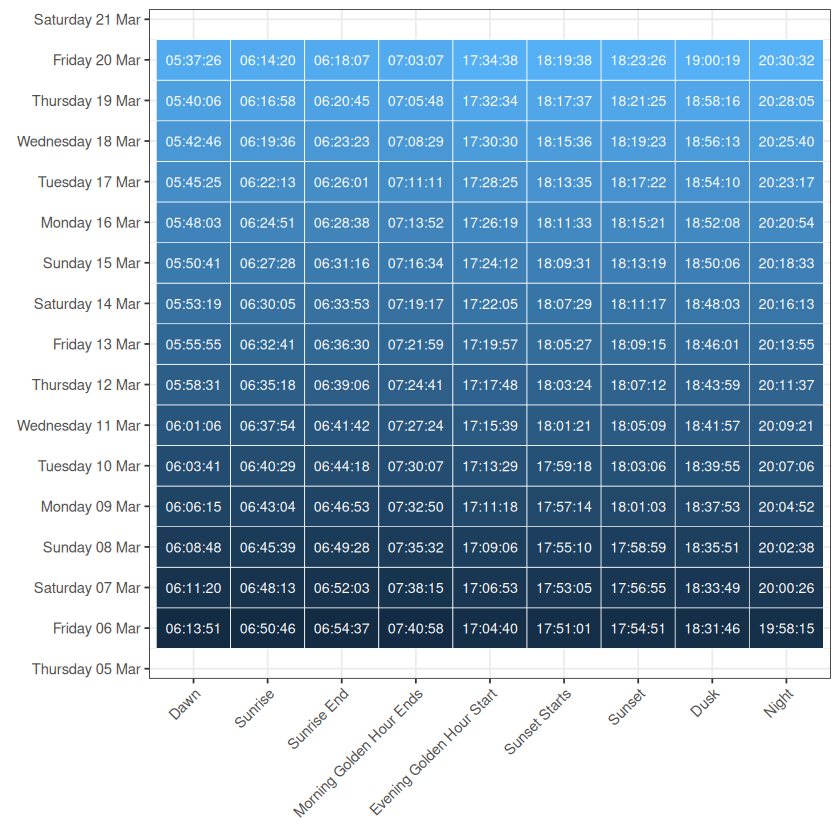

In [50]:
seq_next_14 = 
  seq.Date(Sys.Date()-days(1),Sys.Date()+days(14),by = "1 day")

event_order = c("dawn", 
                "sunrise", 
                "sunriseEnd",
                "goldenHourEnd",
                "goldenHour",
                # "solarNoon", 
                "sunsetStart", 
                "sunset", 
                "dusk", 
                "night")
event_order.labels = c("Dawn", 
                "Sunrise", 
                "Sunrise End",
                "Morning Golden Hour Ends",
                "Evening Golden Hour Start",
                # "solarNoon", 
                "Sunset Starts", 
                "Sunset", 
                "Dusk", 
                "Night")
### Next Week
df.dates.next_week = suncalc::getSunlightTimes(date = seq_next_14,
                            lat = 55.7715024,
                            lon = 12.4932282,
                            tz = "Europe/Copenhagen",
                            keep = event_order) %>% 
  gather(EventName,EventTime,dawn:night) %>% 
  dplyr::mutate(EventName=factor(EventName,levels=event_order,labels=event_order.labels))

df.dates.next_week %>% 
  filter(date>=Sys.Date()) %>% 
  ggplot(.,aes(y=date,x=EventName)) +
  geom_tile(aes(group=EventTime,fill=EventTime),color="white") +
  geom_text(aes(label=format(EventTime, format = "%H:%M:%S", tz = "Europe/Copenhagen")),color="white",size=3) +
  theme_bw() +
  theme(legend.position = "null",
        axis.text.x = element_text(angle = 45, hjust=1)) +
  labs(x=NULL,y=NULL) +
  scale_y_date(date_breaks = "1 day",date_labels = "%A %d %b")

# Next Month

In [52]:
# Sun hours
sunrise = df.dates.next_week %>% filter(EventName=="Sunrise",EventTime>=Sys.Date()) %>% filter(min(EventTime)==EventTime) %>% pull(EventTime) %>% format.Date(.,"%H:%M:%S")
sunset = df.dates.next_week %>% filter(EventName=="Sunset",EventTime>=Sys.Date()) %>% filter(min(EventTime)==EventTime) %>% pull(EventTime) %>% format.Date(.,"%H:%M:%S")

sunrise_dawn = df.dates.next_week %>% filter(EventName=="Dawn",EventTime>=Sys.Date()) %>% filter(min(EventTime)==EventTime) %>% pull(EventTime) %>% format.Date(.,"%H:%M:%S")
sunset_dusk = df.dates.next_week %>% filter(EventName=="Dusk",EventTime>=Sys.Date()) %>% filter(min(EventTime)==EventTime) %>% pull(EventTime) %>% format.Date(.,"%H:%M:%S")

gain_dawn = df.dates.next_week %>% 
  filter(EventName=="Dawn") %>% 
  dplyr::mutate(change=(difftime(lag((EventTime+hours(24))),EventTime,units = "secs"))) %>% 
  dplyr::mutate(change=lubridate::seconds_to_period(change)) %>% 
  dplyr::mutate(change=glue("{ifelse(change$.Data<0,'','-')}{change$minute}:{str_pad(abs(change$.Data),2,pad='0')}")) %>%
  # dplyr::mutate(change=glue("{ifelse(change$.Data<0,'','')}{change$minute}:{str_pad(abs(change$.Data),2,pad='0')}")) %>%
  filter(EventTime>=Sys.Date()) %>% 
  filter(min(EventTime)==EventTime) %>% 
  pull(change)
gain_sunrise = df.dates.next_week %>% 
  filter(EventName=="Sunrise") %>% 
  dplyr::mutate(change=(difftime(lag((EventTime+hours(24))),EventTime,units = "secs"))) %>% 
  dplyr::mutate(change=lubridate::seconds_to_period(change)) %>% 
  dplyr::mutate(change=glue("{ifelse(change$.Data<0,'','-')}{change$minute}:{str_pad(abs(change$.Data),2,pad='0')}")) %>%
  # dplyr::mutate(change=glue("{ifelse(change$.Data<0,'','')}{change$minute}:{str_pad(abs(change$.Data),2,pad='0')}")) %>%
  filter(EventTime>=Sys.Date()) %>% 
  filter(min(EventTime)==EventTime) %>% 
  pull(change)
gain_sunset = df.dates.next_week %>% 
  filter(EventName=="Sunset") %>% 
  dplyr::mutate(change=(difftime(EventTime,lag((EventTime+hours(24))),units = "secs"))) %>% 
  dplyr::mutate(change=lubridate::seconds_to_period(change)) %>% 
  dplyr::mutate(change=glue("{ifelse(change$.Data<0,'-','')}{change$minute}:{str_pad(abs(change$.Data),2,pad='0')}")) %>%
  # dplyr::mutate(change=glue("{ifelse(change$.Data<0,'','')}{change$minute}:{str_pad(abs(change$.Data),2,pad='0')}")) %>%
  filter(EventTime>=Sys.Date()) %>% 
  filter(min(EventTime)==EventTime) %>% 
  pull(change)
gain_dusk = df.dates.next_week %>% 
  filter(EventName=="Dusk") %>% 
  dplyr::mutate(change=(difftime(lag((EventTime+hours(24))),EventTime,units = "secs"))) %>% 
  dplyr::mutate(change=lubridate::seconds_to_period(change)) %>% 
  dplyr::mutate(change=glue("{ifelse(change$.Data<0,'','-')}{change$minute}:{str_pad(abs(change$.Data),2,pad='0')}")) %>%
  # dplyr::mutate(change=glue("{ifelse(change$.Data<0,'','')}{change$minute}:{str_pad(abs(change$.Data),2,pad='0')}")) %>%
  filter(EventTime>=Sys.Date()) %>% 
  filter(min(EventTime)==EventTime) %>% 
  pull(change)
total_gain = df.dates.next_week %>% 
  filter(EventName %in% c("Sunset","Sunrise"))  %>%
  group_by(EventName) %>% 
  dplyr::mutate(change=ifelse(EventName=="Sunrise",
                              (difftime(lag((EventTime+hours(24))),EventTime,units = "secs")),
                              (difftime(EventTime,lag((EventTime+hours(24))),units = "secs")))) %>% 
  filter(EventTime>=Sys.Date()) %>%
  filter(min(EventTime)==EventTime) %>%
  ungroup() %>% 
  dplyr::summarize(change=sum(change)) %>% 
  dplyr::mutate(change=lubridate::seconds_to_period(change)) %>% 
  dplyr::mutate(change=glue("{ifelse(change$.Data<0,'-','')}{change$minute}:{str_pad(abs(change$.Data),2,pad='0')}")) %>%
  pull(change)

# Bike score
msg_bike = tryCatch(expr= {
  bike_score = df.scores %>%
  filter(hour_==7) %>%
  slice(c(1)) %>% 
  dplyr::select(feels_like,pop,uvi,temp,wind_gust,
                feels_like_score,pop_score,uvi_score,temp_score,wind_gust_score)
  temp_ = bike_score$temp
  feels_like = bike_score$feels_like
  pop_ = bike_score$pop
  uvi_ = bike_score$uvi
  wind_gust_ = bike_score$wind_gust
  if (length(feels_like)==0) stop();
  glue("Bike: {scales::number(temp_,accuracy=0.1)} C ({scales::number(feels_like,accuracy=0.1)} C), PoP: {pop_}%, UV: {scales::number(uvi_,accuracy=0.1)}, W: {scales::number(wind_gust_,accuracy=0.1)}")
},error=function(e) {
  glue("Bike: N/A")
})

msg_bikehome = tryCatch(expr= {
  bike_score = df.scores %>%
  filter(hour_==16) %>%
  slice(c(1)) %>% 
  dplyr::select(feels_like,pop,uvi,temp,wind_gust,
                feels_like_score,pop_score,uvi_score,temp_score,wind_gust_score)
  temp_ = bike_score$temp
  feels_like = bike_score$feels_like
  pop_ = bike_score$pop
  uvi_ = bike_score$uvi
  wind_gust_ = bike_score$wind_gust
  if (length(feels_like)==0) stop();
  glue("Bike home: {scales::number(temp_,accuracy=0.1)} C ({scales::number(feels_like,accuracy=0.1)} C), PoP: {pop_}%, UV: {scales::number(uvi_,accuracy=0.1)}, W: {scales::number(wind_gust_,accuracy=0.1)}")
},error=function(e) {
  glue("Bike home: N/A")
})

# Weather forecast
max_uv = df.scores %>% filter(dt %like% format(Sys.Date(),"%A")) %>% dplyr::mutate(dt=paste0(dt)) %>% filter(dt %like% paste(glue("{str_pad(seq(6,22),side = 'left',pad = '0',width=2)}:00"),collapse="|")) %>% pull(uvi) %>% max()
max_temp = df.scores %>% filter(dt %like% format(Sys.Date(),"%A")) %>% dplyr::mutate(dt=paste0(dt)) %>% filter(dt %like% paste(glue("{str_pad(seq(6,22),side = 'left',pad = '0',width=2)}:00"),collapse="|")) %>% pull(temp) %>% max()
min_temp = df.scores %>% filter(dt %like% format(Sys.Date(),"%A")) %>% dplyr::mutate(dt=paste0(dt)) %>% filter(dt %like% paste(glue("{str_pad(seq(6,22),side = 'left',pad = '0',width=2)}:00"),collapse="|")) %>% pull(temp) %>% min()
mean_windgust = df.scores %>% filter(dt %like% format(Sys.Date(),"%A")) %>% dplyr::mutate(dt=paste0(dt)) %>% filter(dt %like% paste(glue("{str_pad(seq(6,22),side = 'left',pad = '0',width=2)}:00"),collapse="|")) %>% pull(wind_gust) %>% mean()
mean_wind = df.scores %>% filter(dt %like% format(Sys.Date(),"%A")) %>% dplyr::mutate(dt=paste0(dt)) %>% filter(dt %like% paste(glue("{str_pad(seq(6,22),side = 'left',pad = '0',width=2)}:00"),collapse="|")) %>% pull(wind_speed) %>% mean()
mean_pop = df.scores %>% filter(dt %like% format(Sys.Date(),"%A")) %>% dplyr::mutate(dt=paste0(dt)) %>% filter(dt %like% paste(glue("{str_pad(seq(6,22),side = 'left',pad = '0',width=2)}:00"),collapse="|")) %>% pull(pop) %>% mean()
mean_clouds = df.scores %>% filter(dt %like% format(Sys.Date(),"%A")) %>% dplyr::mutate(dt=paste0(dt)) %>% filter(dt %like% paste(glue("{str_pad(seq(6,22),side = 'left',pad = '0',width=2)}:00"),collapse="|")) %>% pull(clouds) %>% mean()
best_hours = df.scores %>% filter(dt %like% format(Sys.Date(),"%A")) %>% dplyr::mutate(dt=paste0(dt)) %>% filter(dt %like% paste(glue("{str_pad(seq(6,20),side = 'left',pad = '0',width=2)}:00"),collapse="|")) %>% dplyr::mutate(score=temp_score+uvi_score+clouds_score+wind_gust_score+pop_score) %>% dplyr::slice_max(order_by = score, n = 1, with_ties = FALSE) %>% pull(dt)
msg_forecast = glue("Forecast:\nUVI: {scales::number(max_uv,accuracy=0.1)}, High: {scales::number(max_temp,accuracy=0.1)}, Low: {scales::number(min_temp,accuracy=0.1)}\nPoP: {scales::number(mean_pop,accuracy=0.1)}, Clouds: {scales::number(mean_clouds,accuracy=0.1)}\nWind: {scales::number(mean_wind,accuracy=0.1)}, Windgust: {scales::number(mean_windgust,accuracy=0.1)}\nBest Hour: {best_hours}")

msg_ = glue("Dawn: {sunrise_dawn} ({gain_dawn})\nSunrise: {sunrise} ({gain_sunrise})\nSunset: {sunset} ({gain_sunset})\nDusk: {sunset_dusk} ({gain_dusk})\nTotal gain: {total_gain}\n\n{msg_bike}\n{msg_bikehome}\n\n{msg_forecast}")

msg_daylight_= glue("Dawn: {sunrise_dawn} ({gain_dawn})\nSunrise: {sunrise} ({gain_sunrise})\nSunset: {sunset} ({gain_sunset})\nDusk: {sunset_dusk} ({gain_dusk})\nTotal gain: {total_gain}")

## Next 3 Months

[1]  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25

Warning message:
“Removed 42 rows containing missing values or values outside the scale range
(`geom_line()`).”


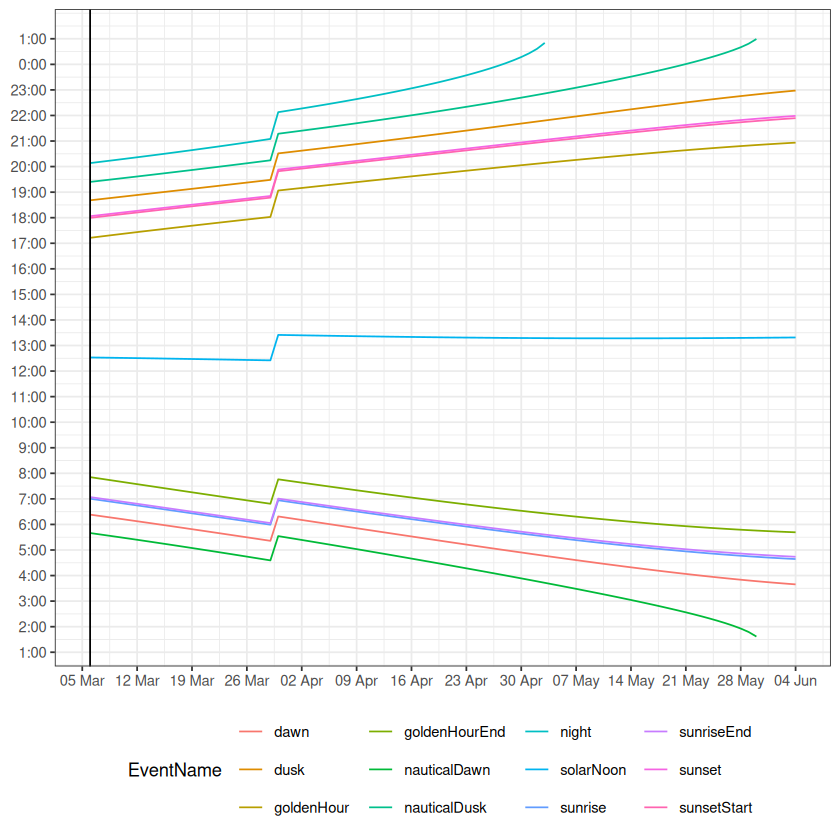

In [53]:
seq_next_3_months = seq.Date(from = Sys.Date(),to = Sys.Date()+90,by = "days")

### Next Week
df.dates.next_3_months =
  suncalc::getSunlightTimes(date = seq_next_3_months,
                            lat = 56.1572,
                            lon = 10.2107,
                            tz = "CET",
                            keep = c("solarNoon", 
                                     "sunrise", 
                                     "sunset", 
                                     "sunriseEnd",
                                     "sunsetStart", 
                                     "dawn", 
                                     "dusk", 
                                     "nauticalDawn", 
                                     "nauticalDusk",
                                     "night", 
                                     "goldenHourEnd", 
                                     "goldenHour")) %>% 
  gather(EventName,EventTime,solarNoon:goldenHour) %>% 
  group_by(date) %>% 
  dplyr::mutate(EventTime=as.numeric(difftime(EventTime,ymd_hms(paste0(date," 00:00:00"),tz = "Europe/Copenhagen"),units = "hours")))

min_time = min(df.dates.next_3_months$EventTime,na.rm = T)
min_time = floor( min_time )

max_time = max(df.dates.next_3_months$EventTime,na.rm = T)
max_time = ceiling( max_time )

seq(min_time,max_time)

ggplot(df.dates.next_3_months,aes(x=date,y = EventTime)) +
  geom_line(aes(color=EventName)) +
  theme_bw() +
  scale_x_date(date_breaks = "7 days",date_labels = "%d %b") +
  theme(legend.position = "bottom") +
  geom_vline(xintercept = Sys.Date()) + 
  scale_y_continuous(breaks = seq(min_time,max_time),labels = paste0(seq(min_time,max_time) %% 24,":00")) +
  labs(x=NULL,y=NULL)

## Next 3 Months

In [54]:
seq_whole_year = seq.Date(from = dmy(paste0("01-01-",year(Sys.Date()))),
                             to = dmy(paste0("31-12-",year(Sys.Date()))),by = "days")

### Next Week
df.dates.next_3_months =
  suncalc::getSunlightTimes(date = seq_whole_year,
                            lat = 56.1572,
                            lon = 10.2107,
                            tz = "CET",
                            keep = c("sunrise", 
                                     "sunset", 
                                     "dawn", 
                                     "dusk")) %>% 
  gather(EventName,EventTime,sunrise:dusk) %>% 
  group_by(date) %>% 
  dplyr::mutate(EventTime=as.numeric(difftime(EventTime,ymd_hms(paste0(date," 00:00:00"),tz = "Europe/Copenhagen"),units = "hours")))

df.dates_today = df.dates.next_3_months %>% filter(date==Sys.Date())

min_time = min(df.dates.next_3_months$EventTime,na.rm = T)
min_time = floor( min_time )

max_time = max(df.dates.next_3_months$EventTime,na.rm = T)
max_time = ceiling( max_time )

seq(min_time,max_time)

p_daylight = ggplot(df.dates.next_3_months,aes(x=date,y = EventTime)) +
  geom_line(aes(color=EventName)) +
  theme_bw() +
  scale_x_date(date_breaks = "7 days",date_labels = "%d %b") +
  theme(legend.position = "bottom") +
  geom_vline(xintercept = Sys.Date()) +
  geom_point(data=df.dates_today,aes(x=date,y=EventTime,color=EventName),shape=4,size=6) +
  scale_y_continuous(breaks = seq(min_time,max_time),labels = paste0(seq(min_time,max_time) %% 24,":00")) +
  scale_x_date(date_breaks = "1 month",date_labels = "%b") +
  labs(x=NULL,y=NULL) +
  geom_label(x=dmy("01-07-2024"),y=13,label=msg_daylight_)

[1]  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24

Scale for x is already present.
Adding another scale for x, which will replace the existing scale.


## 2023

In [55]:
### 2021 Dates
df.dates_2021 =
  suncalc::getSunlightTimes(date = dates_in_thisyear,
                            lat = lat,
                            lon = lon,
                            tz = "CET",
                            keep = c("solarNoon", 
                                     "sunrise", 
                                     "sunset", 
                                     "sunriseEnd",
                                     "sunsetStart", 
                                     "dawn", 
                                     "dusk", 
                                     "nauticalDawn", 
                                     "nauticalDusk",
                                     "night", 
                                     "goldenHourEnd", 
                                     "goldenHour")) %>% 
  gather(EventName,EventTime,solarNoon:goldenHour) %>% 
  group_by(date) %>%
  dplyr::mutate(EventTime=as.numeric(difftime(EventTime,ymd_hms(paste0(date," 00:00:00"),tz = "Europe/Copenhagen"),units = "hours")))

# min_time = min(dates_in_thisyear$EventTime,na.rm = T)
# min_time = floor( min_time )

# max_time = max(dates_in_thisyear$EventTime,na.rm = T)
# max_time = ceiling( max_time )


# ggplot(df.dates_2021,aes(x=date,y = EventTime)) +
  # scale_x_date(date_breaks = "1 month",date_labels = "%b") +
  # geom_point(aes(color=EventName)) +
  # theme_bw()+
  # theme(legend.position = "bottom") +
  # geom_vline(xintercept = Sys.Date())  +
  # scale_y_continuous(breaks = seq(min_time,max_time),labels = paste0(seq(min_time,max_time) %% 24,":00")) +
  # labs(x=NULL,y=NULL)

## Change in daylight coming weeks

Warning message:
“Removed 12 rows containing missing values or values outside the scale range
(`geom_line()`).”


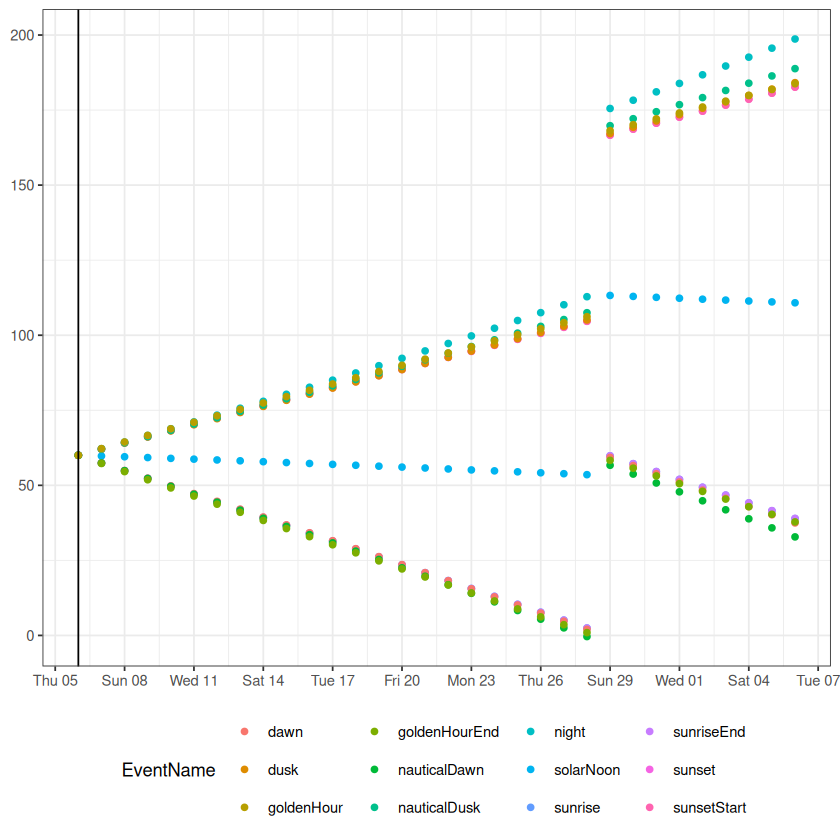

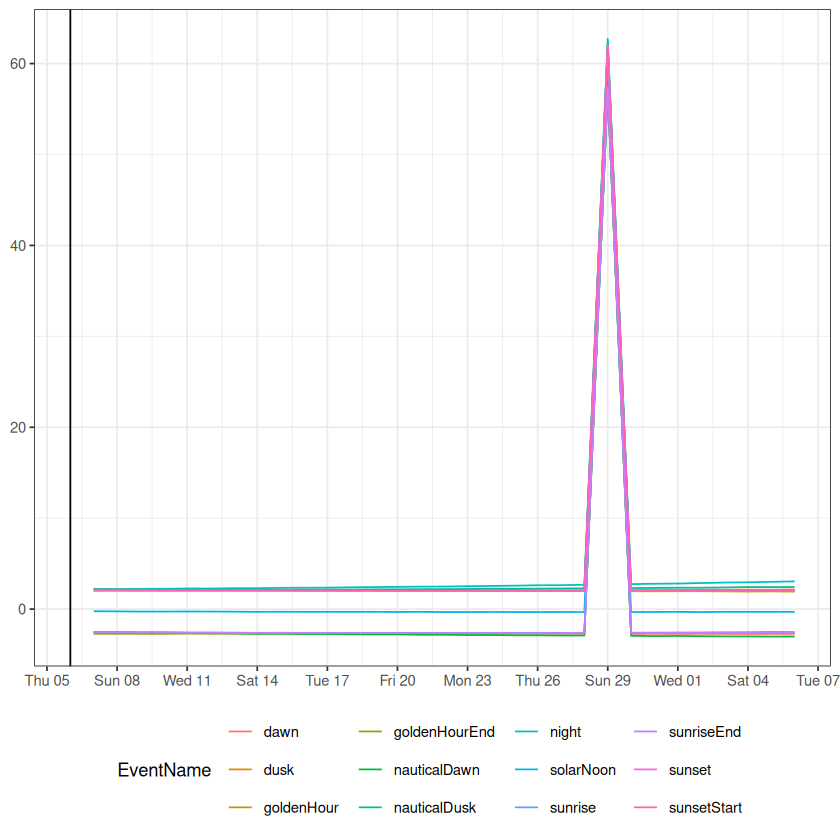

In [56]:
### 2021 Dates
df.dates =
  suncalc::getSunlightTimes(date = dates_in_thisyear,
                            lat = lat,
                            lon = lon,
                            tz = "CET",
                            keep = c("solarNoon", 
                                     "sunrise", 
                                     "sunset", 
                                     "sunriseEnd",
                                     "sunsetStart", 
                                     "dawn", 
                                     "dusk", 
                                     "nauticalDawn", 
                                     "nauticalDusk",
                                     "night", 
                                     "goldenHourEnd", 
                                     "goldenHour")) %>% 
  gather(EventName,EventTime,solarNoon:goldenHour) %>% 
  filter(date>=Sys.Date()) %>% 
  filter(date<=Sys.Date()+months(1)) %>% 
  group_by(EventName) %>% 
  dplyr::mutate(StartTime=EventTime) %>% 
  dplyr::mutate(StartTime=ifelse(StartTime==min(EventTime),StartTime,NA)) %>% 
  tidyr::fill(StartTime) %>% 
  group_by(EventName) %>% 
  dplyr::mutate(StartTime=as.POSIXct(StartTime,origin="1970-01-01"),tz="CET") %>% 
  dplyr::mutate(StartTime=ymd_hms(paste0(year(EventTime),"-",month(EventTime),"-",day(EventTime)," ",hour(StartTime),":",minute(StartTime),":",second(StartTime)),tz="CET")) %>% 
  dplyr::mutate(EventTime=as.POSIXct(EventTime,tz="CET")) %>% 
dplyr::mutate(MinutesChanged=round(as.numeric(difftime(EventTime,StartTime,units="mins")),digits=2)) %>% 
  dplyr::mutate(DailyChange=MinutesChanged-lag(MinutesChanged))


ggplot(df.dates,aes(x=date,y = MinutesChanged)) +
  scale_x_date(date_breaks = "3 days",date_labels = "%a %d") +
  geom_point(aes(color=EventName)) +
  theme_bw() +
  theme(legend.position = "bottom") +
  geom_vline(xintercept = Sys.Date())  +
  labs(x=NULL,y=NULL)


ggplot(df.dates,aes(x=date,y = DailyChange)) +
  scale_x_date(date_breaks = "3 days",date_labels = "%a %d") +
  geom_line(aes(color=EventName)) +
  theme_bw() +
  theme(legend.position = "bottom") +
  geom_vline(xintercept = Sys.Date())  +
  labs(x=NULL,y=NULL)

# Send out

In [57]:
msg_

Dawn: 06:13:51 (-2:30)
Sunrise: 06:50:46 (-2:33)
Sunset: 17:54:51 (2:05)
Dusk: 18:31:46 (-2:02)
Total gain: 4:38

Bike: 4.4 C (2.7 C), PoP: 0%, UV: 0.0, W: 1.9
Bike home: 8.8 C (7.2 C), PoP: 0%, UV: 0.3, W: 4.4

Forecast:
UVI: 1.4, High: 9.2, Low: 2.6
PoP: 0.0, Clouds: 28.1
Wind: 3.0, Windgust: 5.2
Best Hour: Friday 15:00

In [58]:
tmp_dir = tempdir()
ggsave(filename = paste0(tmp_dir,"/sunlight.jpg"),plot = p_daylight,device = "jpeg")
ggsave(filename = paste0(tmp_dir,"/forecast.jpg"),plot = todays_forecast,device = "jpeg")
ggsave(filename = paste0(tmp_dir,"/beach_forecast.jpg"),plot = todays_beach_forecast,device = "jpeg")

# Check if Pushover is properly configured before sending
pushover_app_key <- Sys.getenv("PUSHOVER_APPKEY")
pushover_user_key <- Sys.getenv("PUSHOVER_USERKEY")

if (nchar(pushover_app_key) >= 30 && nchar(pushover_user_key) >= 30) {
  cat("Sending Pushover notifications...\n")
  pushoverr::pushover("Sunlight",attachment = paste0(tmp_dir,"/sunlight.jpg"))
  pushoverr::pushover("Today's Forecast",attachment = paste0(tmp_dir,"/forecast.jpg"))
  # pushoverr::pushover("Today's Beach Forecast",attachment = paste0(tmp_dir,"/beach_forecast.jpg"))
  pushoverr::pushover(msg_)
  cat("Pushover notifications sent successfully!\n")
} else {
  cat("Pushover not configured properly. Check your environment variables:\n")
  cat("PUSHOVER_APPKEY length:", nchar(pushover_app_key), "(need ≥30)\n")
  cat("PUSHOVER_USERKEY length:", nchar(pushover_user_key), "(need ≥30)\n")
  cat("Message that would have been sent:\n")
  cat(msg_)
}

Saving 6.67 x 6.67 in image


Saving 6.67 x 6.67 in image
Saving 6.67 x 6.67 in image


Pushover not configured properly. Check your environment variables:
PUSHOVER_APPKEY length: 0 (need ≥30)
PUSHOVER_USERKEY length: 0 (need ≥30)
Message that would have been sent:
Dawn: 06:13:51 (-2:30)
Sunrise: 06:50:46 (-2:33)
Sunset: 17:54:51 (2:05)
Dusk: 18:31:46 (-2:02)
Total gain: 4:38

Bike: 4.4 C (2.7 C), PoP: 0%, UV: 0.0, W: 1.9
Bike home: 8.8 C (7.2 C), PoP: 0%, UV: 0.3, W: 4.4

Forecast:
UVI: 1.4, High: 9.2, Low: 2.6
PoP: 0.0, Clouds: 28.1
Wind: 3.0, Windgust: 5.2
Best Hour: Friday 15:00